# Explore Combined Estimation File

Data tabulations and summaries from estimation file to understand the results better. 

In [19]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.reset_option('display.float_format')


In [20]:
df = pd.read_csv('out/combined_estimation_file.csv')
df.head()

C:\Users\ger225\AppData\Local\Temp\ipykernel_15544\1539831039.py:1: DtypeWarning: Columns (0: depart_date, 1: linked_trip_mode_labeled, 2: income_labeled) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('out/combined_estimation_file.csv')


,Unnamed: 0,hh_id,person_id,person_num,day_id,day_num,depart_date,o_tract_2020,d_tract_2020,linked_trip_id,linked_trip_num,linked_trip_mode,linked_trip_weight,linked_trip_mode_labeled,mode,mode2,distance_miles,duration_minutes,o_district,d_district,o_community,d_community,time_period,ff_car_time_minutes,car_ivt,tnc_wait,tnc_time,tnc_fare,transit_fare,walk_time,transit_time,transit_or_walk_time,walk_faster_than_transit,transit_or_walk_fare,income_broad,income_labeled,hh_share_inc_under_100k,hh_share_inc_over_100k,tnc_trip_id,obs_fare,obs_tip,obs_additional_charges,transit_avail,walk_avail,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk,transit_or_walk_avail
0,0,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031320101,17031081500,2.400012e+15,1.0,15.0,1853.792592,Walk,walk,walk,0.810270,20.0,Downtown,Downtown,32.0,8.0,midday,3.738333,6.186942,5,11.186942,6.707731,2.5,16.205401,22.0,16.205401,True,0.0,5.0,"$150,000 or more",0.341000,0.659000,NaN,NaN,NaN,NaN,1,1,-5.018459,6.707731,1
1,1,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031081500,17031081403,2.400012e+15,2.0,15.0,1853.792592,Walk,walk,walk,0.338027,28.0,Downtown,Downtown,8.0,8.0,midday,1.660000,2.747300,5,7.747300,4.798943,2.5,6.760535,7.0,6.760535,True,0.0,5.0,"$150,000 or more",0.321678,0.678322,NaN,NaN,NaN,NaN,1,1,0.986765,4.798943,1
2,2,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031081403,17031320101,2.400012e+15,3.0,15.0,1853.792592,Walk,walk,walk,0.549293,15.0,Downtown,Downtown,8.0,32.0,midday,3.421667,5.662858,5,10.662858,6.244886,2.5,10.985870,23.0,10.985870,True,0.0,5.0,"$150,000 or more",0.460539,0.539461,NaN,NaN,NaN,NaN,1,1,-0.323012,6.244886,1
3,3,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031320101,17031320101,2.400012e+15,4.0,15.0,1853.792592,Walk,walk,walk,0.319386,16.0,Downtown,Downtown,32.0,32.0,midday,2.201667,3.643758,5,8.643758,5.167457,2.5,6.387712,12.0,6.387712,True,0.0,5.0,"$150,000 or more",0.341000,0.659000,NaN,NaN,NaN,NaN,1,1,2.256047,5.167457,1
4,4,24000124.0,2.400012e+09,2.0,2.400012e+11,1.0,2024-05-21,17031320101,17031320102,2.400012e+15,1.0,15.0,1853.792592,Walk,walk,walk,0.751861,16.0,Downtown,Downtown,32.0,32.0,midday,2.201667,3.643758,5,8.643758,5.561010,2.5,15.037220,12.0,12.000000,False,2.5,5.0,"$150,000 or more",0.341000,0.659000,NaN,NaN,NaN,NaN,1,1,-3.356242,3.061010,1


In [21]:
# some scatterplots

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='tnc_time', y='transit_or_walk_time', hue='mode', , alpha=0.1, s=2)
plt.xlabel('TNC time')
plt.ylabel('Transit or walk time')
plt.legend(title='Mode')
plt.show()

SyntaxError: invalid syntax (4079677155.py, line 4)

What we see above is a strange bifurcated distribution.  Why is this?  I'm guessing it is about whether or not transit/walk is available.

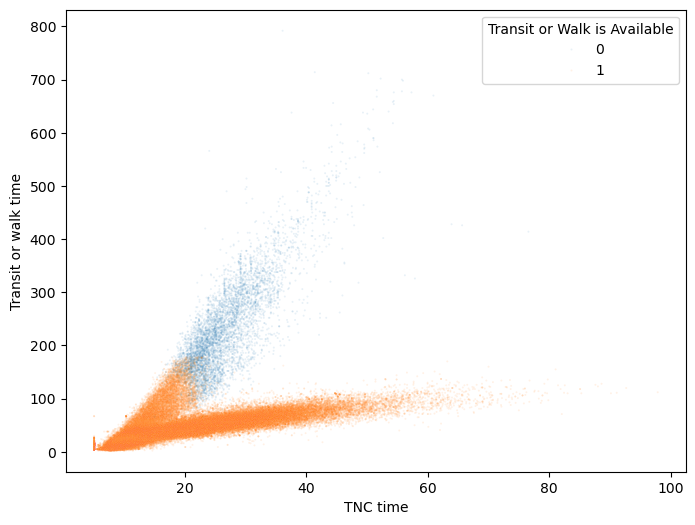

In [ ]:
# some scatterplots

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='tnc_time', y='transit_or_walk_time', hue='transit_or_walk_avail', alpha=0.1, s=2)
plt.xlabel('TNC time')
plt.ylabel('Transit or walk time')
plt.legend(title='Transit or Walk is Available')
plt.show()

Yes, that seems to be the case.  Let's summarize things to see when and where transit/walk are available. 

In [ ]:
# transit vs walk availability

# TNC
tnc = df[df['mode']=='tnc']
print('TNC Trips - Observations')
display(pd.crosstab(tnc['walk_avail'], tnc['transit_avail'], margins=True).style.format('{:,.0f}'))

# Transit
transit = df[df['mode']=='transit']
print('Transit Trips - Observations')
display(pd.crosstab(transit['walk_avail'], transit['transit_avail'], margins=True).style.format('{:,.0f}'))

# Walk
walk = df[(df['mode']=='walk')]
print('Walk Trips - Observations')
display(pd.crosstab(walk['walk_avail'], walk['transit_avail'], margins=True).style.format('{:,.0f}'))


TNC Trips - Observations


transit_avail,0,1,All
walk_avail,,,
0,"5,646","76,901","82,547"
1,0,"73,799","73,799"
All,"5,646","150,700","156,346"


Transit Trips - Observations


transit_avail,1,All
walk_avail,,
0,"1,047","1,047"
1,536,536
All,"1,583","1,583"


Walk Trips - Observations


transit_avail,1,All
walk_avail,,
1,"3,516","3,516"
All,"3,516","3,516"


In [ ]:
# transit availability by time of day

# TNC
tnc = df[df['mode']=='tnc']
print('TNC Trips - Observations')
display(pd.crosstab(tnc['time_period'], tnc['transit_avail'], margins=True).style.format('{:,.0f}'))

# Transit
transit = df[df['mode']=='transit']
print('Transit Trips - Observations')
display(pd.crosstab(transit['time_period'], transit['transit_avail'], margins=True).style.format('{:,.0f}'))

# Walk
walk = df[(df['mode']=='walk')]
print('Walk Trips - Observations')
display(pd.crosstab(walk['time_period'], walk['transit_avail'], margins=True).style.format('{:,.0f}'))


TNC Trips - Observations


transit_avail,0,1,All
time_period,,,
am_peak,4,"20,756","20,760"
evening,5,"27,989","27,994"
midday,13,"54,540","54,553"
night,"5,611","18,300","23,911"
pm_peak,13,"29,115","29,128"
All,"5,646","150,700","156,346"


Transit Trips - Observations


transit_avail,1,All
time_period,,
am_peak,404,404
evening,130,130
midday,542,542
night,36,36
pm_peak,471,471
All,"1,583","1,583"


Walk Trips - Observations


transit_avail,1,All
time_period,,
am_peak,490,490
evening,341,341
midday,"1,610","1,610"
night,109,109
pm_peak,966,966
All,"3,516","3,516"


We see that it's dominantly at night when transit is not available, which is what we expect. 

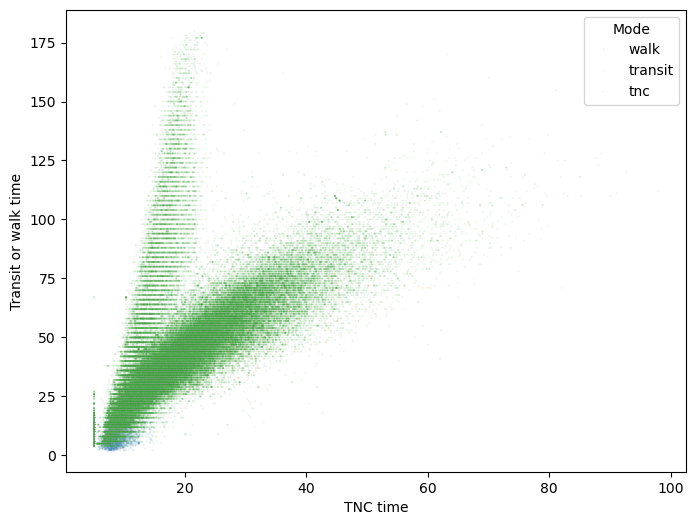

In [ ]:
# same scatterplots, but exclude cases where transit and walk are both unavailable

avail_df = df[df['transit_or_walk_avail']==1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=avail_df, x='tnc_time', y='transit_or_walk_time', hue='mode', alpha=0.1, s=2)
plt.xlabel('TNC time')
plt.ylabel('Transit or walk time')
plt.legend(title='Mode')
plt.show()

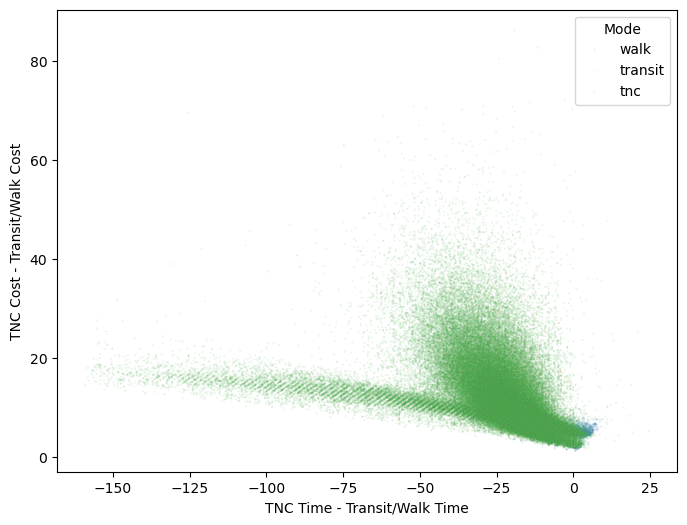

In [ ]:
# some scatterplots

avail_df = df[df['transit_or_walk_avail']==1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=avail_df, x='tnc_time_minus_transit_walk', y='tnc_cost_minus_transit_walk', hue='mode', alpha=0.1, s=2)
plt.xlabel('TNC Time - Transit/Walk Time')
plt.ylabel('TNC Cost - Transit/Walk Cost')
plt.legend(title='Mode')
plt.show()

In [22]:
tail = df[(df['transit_or_walk_avail']==1) & (df['tnc_time_minus_transit_walk']<-60)]
tail.to_csv('out/tail.csv')

When I look at the tail above, they are dominantly night time trips.  That mostly makes sense. 

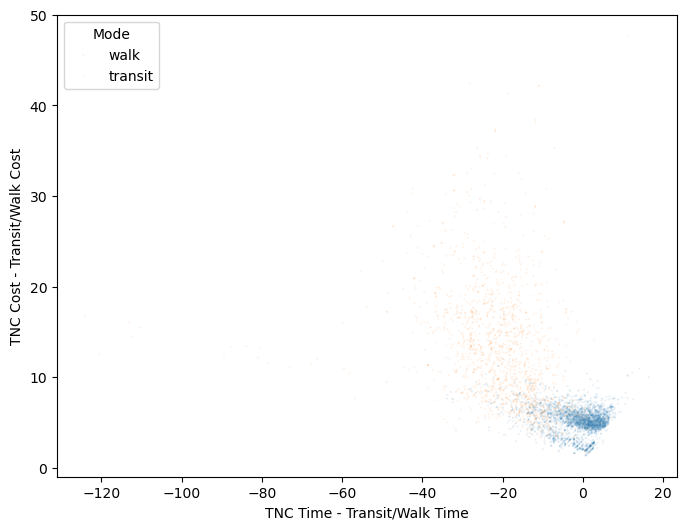

In [23]:
# same plot, but make it easier to see just the transit/walk

subset = df[(df['transit_or_walk_avail']==1) & (df['mode']!='tnc')]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=subset, x='tnc_time_minus_transit_walk', y='tnc_cost_minus_transit_walk', hue='mode', alpha=0.1, s=2)
plt.xlabel('TNC Time - Transit/Walk Time')
plt.ylabel('TNC Cost - Transit/Walk Cost')
plt.legend(title='Mode')
plt.show()